# Numerical vs. Neurical Solutions for a Single-Phase Problem

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1X3UQadRKmtdI7MK6hP1HsHY2DJvO41g8/view?usp=drive_link&target=_blank)

*Author: Zakariya Abugrin | Date: May 2025*

In [1]:
# Colab only:
try:
    # Install reservoirflow in Colab
    import os
    import google.colab
    !pip install reservoirflow
    # Restart session after installation
    os.kill(os.getpid(), 9)
    print("Session was restarted.")
    print("Now you can run to the following cells.")
except ImportError:
    pass

## Introduction

Numerical solutions fully based on physics requires extensive domain knowledge to develop. Moreover, simulation runs based on these models remain computationally expensive, limiting the ability to take real-time decisions. Alternatively, AI proxy models trained on simulation data are used to capture the physics implicitly to be used for fast prediction. However, these models remain dependent on reservoir simulation data and can't be extended beyond the training data. 

## Prerequisites:
Before you can follow this tutorial, you need to understand the following tutorials:
1. [Understand scalers Module](/user_guide/tutorials/tutorial_understand_scalers_module.html).
2. [Understand Compiling](/user_guide/tutorials/tutorial_understand_compiling.html).

<!-- ![image](grid_animated.gif) -->
![image](https://drive.google.com/thumbnail?id=1M4DAZ_AjIVYES2WEEaFMY34Gm3-iDRf9&sz=w1000)\
**the code used to generate this gif image is shown in [Save simulation run as gif](#save-simulation-run-as-gif) section below.*

## Import `reservoirflow`

We start with importing `reservoirflow` as `rf`. The abbreviation `rf` refers to `reservoirflow` where all modules under this library can be accessed. `rf` is also used throughout the [API](/api/API.html) documentation. We recommend our users to stick with this convention.

In [2]:
import reservoirflow as rf

print(rf.__version__)

0.1.0b3


In [3]:
static = notebook = True

- Both `static` and `notebook` are set to `True` to produce images for this notebook. For an interactive visualization in your local machine, set both arguments to `False`. To allow for interactive visualizations in Colab, set only `static=False` and keep `notebook=True`. 

In [4]:
rf.utils.pyvista.set_mode("dark")

- By default, `"dark"` mode is used with a black background. You can change to `"light"` mode using `rf.utils.pyvista.set_mode()` function. 

In [5]:
g_comp = 1e-6
f_comp = 1e-5
nx=50
ny=50
ny=3
dx=300
dy=350
dz=40
phi=0.27
kx=270
ky =270
kz = 50
nsteps=100
n_w=2 
dtype="double" 
verbose=False
boundary=False

## Define a regular cartesian grid

We start with defining the grid model which represents the rock geometry and properties using `grids` module. Currently, only `RegularCartesian` grid models are supported. In the near future, `Radial` and `IrregularCartesian` models will be added.

In [6]:
# Grid:
grid_1d = rf.grids.RegularCartesian(
    nx=nx,
    ny=1,
    nz=1,
    dx=dx,
    dy=dy,
    dz=dz,
    phi=phi,
    kx=kx,
    # ky=270,
    # kz=50,
    comp=g_comp,
    dtype=dtype,
)
# Grid:
grid_2d = rf.grids.RegularCartesian(
    nx=nx,
    ny=nx,
    nz=1,
    dx=dx,
    dy=dy,
    dz=dz,
    phi=phi,
    kx=kx,
    ky=ky,
    # kz=50,
    comp=g_comp,
    dtype=dtype,
)
# Grid:
grid_3d = rf.grids.RegularCartesian(
    nx=nx,
    ny=nx,
    nz=3,
    dx=dx,
    dy=dy,
    dz=dz,
    phi=phi,
    kx=kx,
    ky=ky,
    kz=kz,
    comp=g_comp,
    dtype=dtype,
)

```{note}
Note that `field` units are used in this tutorial. For more information about selecting a unit system or what units or factors are used for each property, see [Units & Factors](/user_guide/units_factors/units_factors.html).
```

The grid object can be shown using `show()` method. Argument `label` can be used to show cells id or other properties. For more information, check [`RegularCartesian`](/api/reservoirflow.grids.RegularCartesian.html).

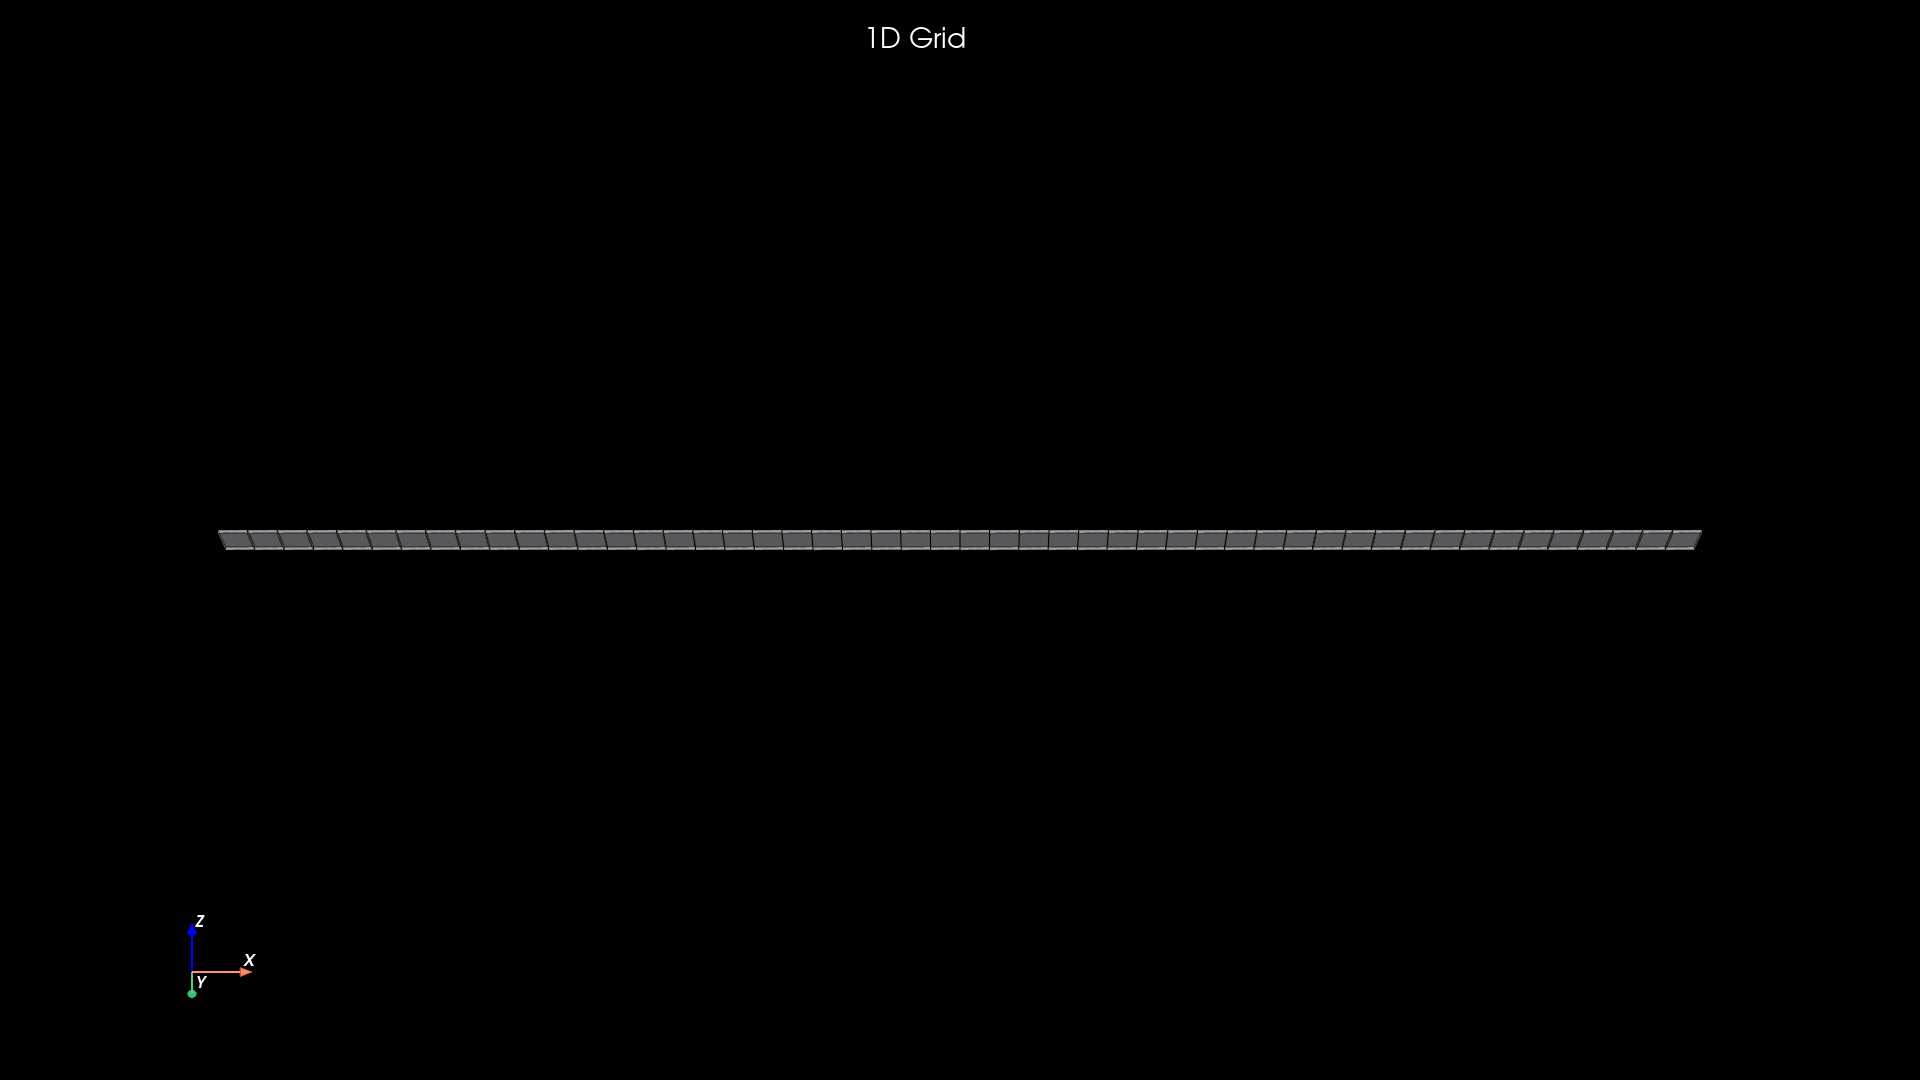

In [30]:
grid_1d.show(
    title="1D Grid",
    # label="id",
    boundary=boundary,
    static=static,
    notebook=notebook,
    azimuth=0,
    elevation=-30,
    zoom=1.4,
)

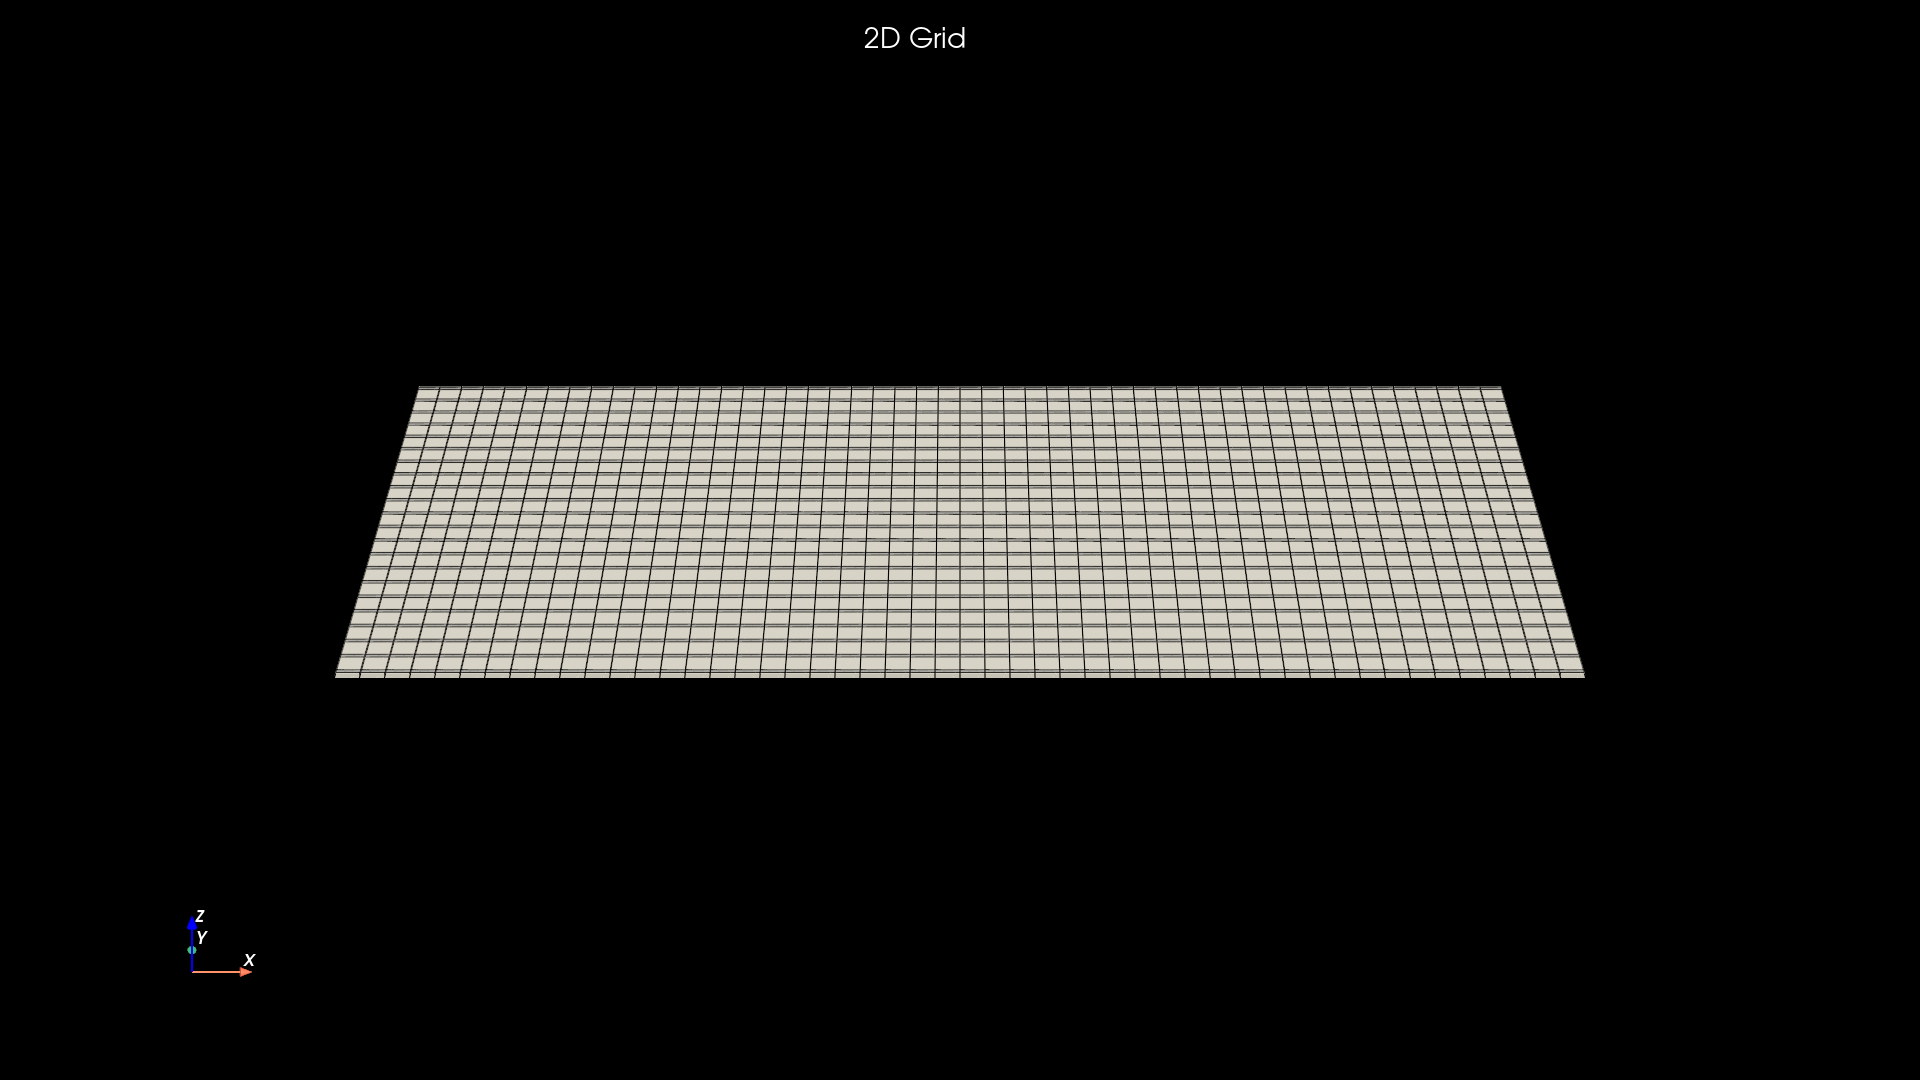

In [25]:
grid_2d.show(
    title="2D Grid",
    # label="id",
    boundary=boundary,
    static=static,
    notebook=notebook,
    azimuth=0,
    elevation=-60,
    zoom=1.7,
)

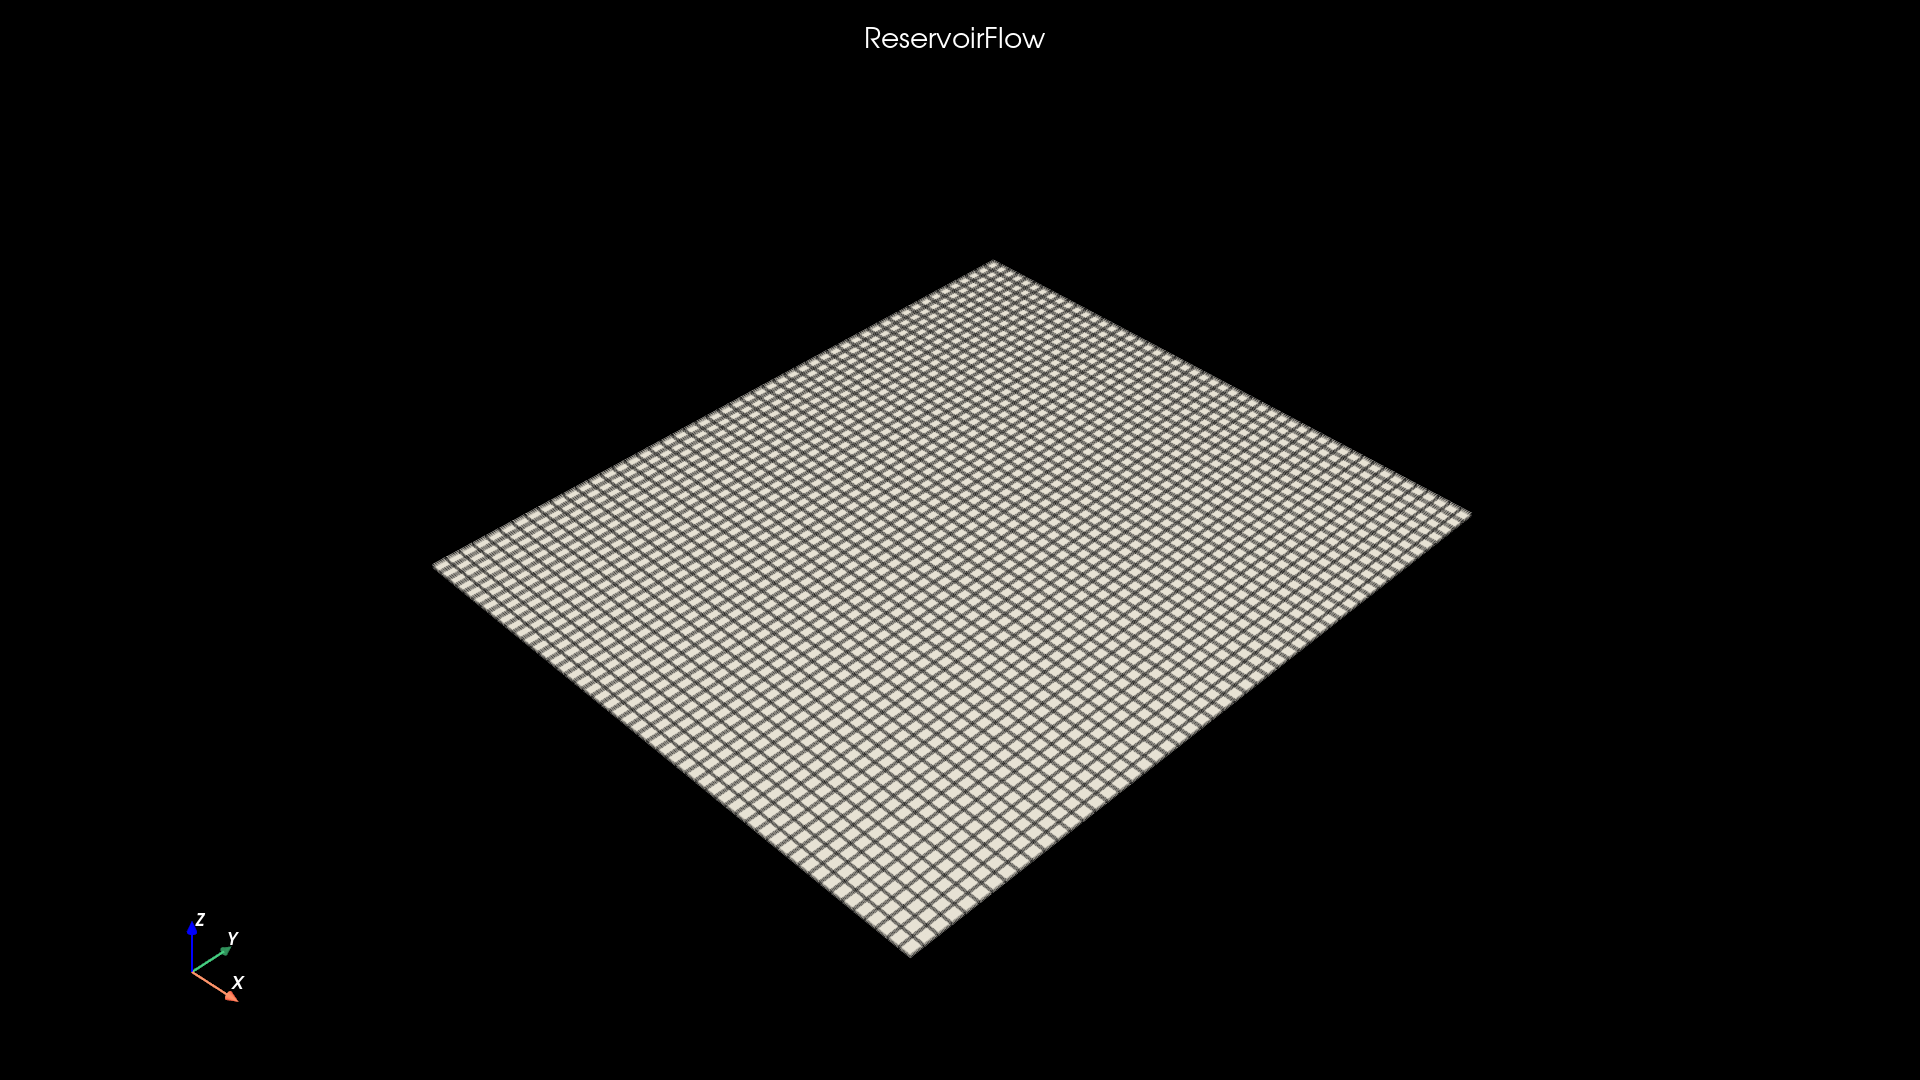

In [9]:
grid_3d.show(
    # label="id",
    boundary=boundary,
    static=static,
    notebook=notebook,
)

```{note}
Cells are given an id based on natural order starting form the bottom left corner, see `grid.cells_id`. Cells id increase in x from left to right, in y from front to back, and in z from bottom to top. Boundaries are also counted. You can use the cell id to access its properties, or add a well in that location as shown in [Add wells](#add-wells) section below.
```

## Define a single phase compressible fluid

After defining the grid model, we can use the `fluids` module to define a fluid. A single phase fluid can be defined using `SinglePhase` class which accepts arguments such s viscosity (mu), formation volume factor (B), density (rho), compressibility (comp) etc. For more information, check [`SinglePhase`](/api/reservoirflow.fluids.SinglePhase.html).

In [10]:
fluid = rf.fluids.SinglePhase(
    mu=0.5,
    B=1,
    rho=50,
    comp=f_comp,
    dtype=dtype,
)

## 1D Grid



In [11]:
model_1d = rf.models.BlackOil(
    grid=grid_1d,
    fluid=fluid,
    pi=4000,
    dt=1,
    start_date="01.01.2000",
    unit="field",
)

# Boundaries:
model_1d.set_boundaries(
    {
        0: ("pressure", 1000),  # left boundary
        nx + 1: ("pressure", 4000),  # right boundary
    }
)
# Numerical solution:
model_1d.compile(
    stype="numerical",
    method="FDM",
    sparse=False,
    name=f"FDM",  # name of the solution
).run(nsteps=nsteps)
# Neurical solution:
model_1d.compile(
    stype="neurical",
    method="PINN",
    sparse=False,
    name=f"PINN",
).run(nsteps=nsteps)

[info] FDM was assigned as model.solution.
[info] Simulation run started: 100 timesteps.


[step]: 100%|██████████| 100/100 [00:00<00:00, 787.88steps/s]

[info] Simulation run of 100 steps finished in 0.14 seconds.
[info] Material Balance Error: 2.339239912885205e-12.


[info] PINN was assigned as model.solution.
[info] pressures array shape was updated. This happens due to increasing nsteps manually or due to solutions in multiple nsteps.
[info] rates array shape was updated. This happens due to increasing nsteps manually or due to solutions in multiple nsteps.
[info] Simulation run started: 100 timesteps.
w_r 0.046221570066030816
w_d 0.9537784299339692
S_px: 2.5631167499679612e-05 S_pt: 15.0 S_q: 1


[epoch] 100 - [loss total] 0.037072 - [loss test] 0.032095 - [loss data] 0.033335 - [loss residual] 0.114184: 100%|██████████| 100/100 [00:29<00:00,  3.42epochs/s]


[info] Pinn fitting of 100 epochs finished in 0.487 minutes -  loss (test): 0.032095.


[epoch] 100 - [loss total] 0.009262 - [loss test] 0.008941 - [loss data] 0.008941 - [loss residual] 0.015882: 100%|██████████| 100/100 [01:12<00:00,  1.37epochs/s]

[info] Pinn fitting of 100 epochs finished in 1.214 minutes -  loss (test): 0.008941.
[info] Simulation run of 100 steps finished in 104.18 seconds.
[info] Material Balance Error: 1.0219579560710894.


In [12]:
model_1d.print_solutions()

╭────┬────────┬───────────┬──────────┬──────────┬─────────┬──────────┬─────────┬───────────────┬───────────────╮
│    │ name   │ stype     │ method   │ sparse   │   tstep │   nsteps │   ctime │   tstep_error │   ctime_error │
├────┼────────┼───────────┼──────────┼──────────┼─────────┼──────────┼─────────┼───────────────┼───────────────┤
│  0 │ FDM    │ Numerical │ FDM      │ False    │     100 │      101 │    0.14 │   2.33924e-12 │    0.01       │
│  1 │ PINN   │ Neurical  │ PINN     │ False    │     100 │      101 │  104.18 │   1.02196     │    0.00447802 │
╰────┴────────┴───────────┴──────────┴──────────┴─────────┴──────────┴─────────┴───────────────┴───────────────╯
(*)
 - stype: solution type.
 - method: solution method.
 - sparse: whether the solution uses sparse computing.
 - tstep: last time step.
 - nsteps: total number of steps in the solution.
 - ctime: cumulative computing time (sec).
 - error: material balance error.



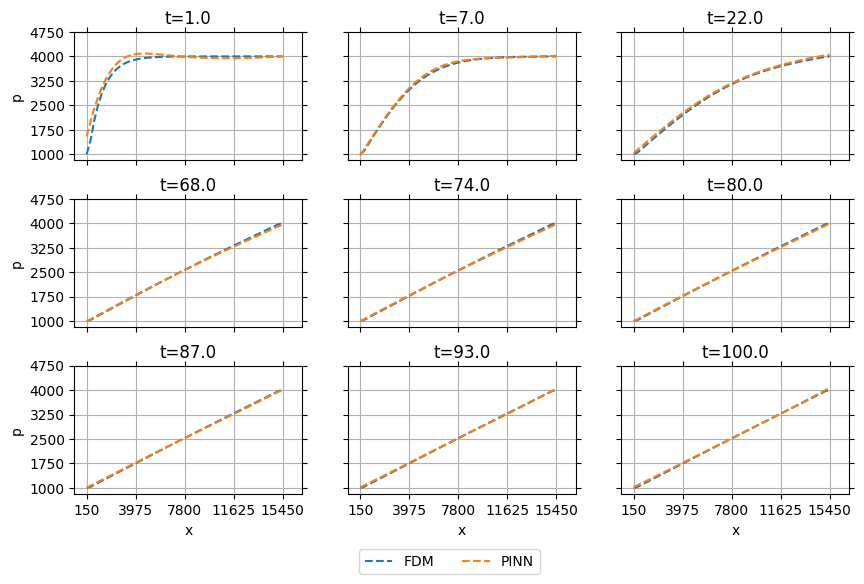

In [13]:
model_1d.plot(solution="all", scale=False)

## Compile the model

Before you can run the model, you need to compile a solution for it. By compiling a solution, you actually decide the solution you want to use for your model. Interestingly, `reservoirflow` provides multiple solutions for the same model based on your configuration. 

```{hint}
Compiling solutions is the most interesting idea introduced in ``reservoirflow`` which allows to solve the same model using different solutions so we can compare them with each other and/or combine them together.
```

Currently, a `numerical` solution based on Finite-Difference-Method (`FDM`) is available. You can read more about the available solution in the [`solutions`](/api/reservoirflow.solutions.html). Below, we compile our model using a `numerical` solution using `FDM`.

In [14]:
model.compile(stype="numerical", method="FDM", sparse=False)

NameError: name 'model' is not defined

```{attention}
A model can not be run until it is complied. Methods such as ``solve()`` and ``run()`` will be functioning only after the model is compiled.
```

## Run the model with 40 time steps

To run the simulation model, use `run()` method as shown below. Here, you can set the number of time steps based on `nsteps` argument. Note that each time step will have a time duration as defined by `dt` argument when the model was constructed. 

There are two modes available run the model based on `vectorize` argument, `True` means vectorized and `False` means symbolized. In addition, you can also select a solver which can be `direct`, `iterative`, or `neurical`. Developing solvers based on neural-networks is also a new idea introduced by ``reservoirflow``.

<!-- ```{tip}
- Use ``vectorize=True`` mode for better performance especially when you have a large model. 
- Use ``vectorize`` mode only to see how the system of linear equations is built which might be very useful for small models and to verify the `vectorized` implementation. 
- Use ``direct`` for a lower computing errors as long as ``iterative`` does not offer any additional performance boost. For now, ``neurical`` solvers remains one of our research topics.
``` -->

In [ ]:
model.run(
    nsteps=40,
    vectorize=True,
    isolver=None,
)

## Visualize the simulation run in 3D show

You can interactively show the simulation run in a 3D show using `show()` method. There is a lot of functionality here. For interactive visualization, set `static` and `notebook` to `False`. For more information, check the [`BlackOil.show()`](/api/reservoirflow.models.BlackOil.show.html#reservoirflow.models.BlackOil.show). 

```{note}
Here, boundaries are also added (`boundary=True`) but they appear in a gray color. That is because boundaries are defined as a zero flow rate where pressures are undefined (i.e. `np.nan`). If boundary conditions were set to constant pressures, values will appear based on the defined color map.
```

In [ ]:
model.show(
    prop="pressures",
    boundary=True,
    cmap="Blues",
    static=static,
    notebook=notebook,
)

```{tip}
Use the color maps names as `str` with `cmap` argument. Matplotlib color maps are supported, for more color maps, check [Choosing Colormaps in Matplotlib](https://matplotlib.org/stable/users/explain/colors/colormaps.html). In the above image, `cmap="Blues"` was used. In [Save simulation run as gif](#save-simulation-run-as-gif) section below, `cmap="tab10"` was used instead. 
```

## Show results as a pandas `DataFrame`

The results of the Simulation run can be accessed as a pandas `DateFrame` using `get_df()` method. You can select `columns` and `scale` values. For more information, check [`BlackOil.get_df()`](/api/reservoirflow.models.BlackOil.get_df.html#reservoirflow.models.BlackOil.get_df).

In [ ]:
df = model.get_df(columns=["time", "date", "wells"], units=True).round()
df

## Save simulation run as gif

You can save gif movie of the simulation run using `save_gif()` method. For more information, check the [`BlackOil.save_gif()`](/api/reservoirflow.models.BlackOil.save_gif.html#reservoirflow.models.BlackOil.save_gif).

In [ ]:
if not static:
    model.save_gif(
        prop="pressures",
        boundary=False,
        cmap="tab10",
        file_name="attachments/grid_animated.gif",
        window_size=rf.utils.pyvista.get_window_size("hd"),
    )

```{tip}
To save a gif movie of the simulation run, set `static=False` or just remove the first line and unindent.
```

```{include} /_static/comments_section.md
```